In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier

import pickle

In [22]:
X = pd.read_csv("../data/feature_store/smart_features.csv")
y = pd.read_csv("../data/feature_store/smart_target.csv").values.ravel()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Features shape: (891, 28)
Target shape: (891,)


,toss_winner_is_team1,team1_win_rate,team2_win_rate,team1_recent_form,team2_recent_form,win_rate_diff,form_diff,win_rate_ratio,form_ratio,h2h_clipped,...,team1_sunrisers hyderabad,team2_delhi capitals,team2_gujarat titans,team2_kolkata knight riders,team2_lucknow super giants,team2_mumbai indians,team2_punjab kings,team2_rajasthan royals,team2_royal challengers bangalore,team2_sunrisers hyderabad
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,49999,49999,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [23]:
print("\nChecking missing values:")
print(X.isnull().sum())

print("\nTarget distribution:")
print(pd.Series(y).value_counts())


Checking missing values:
toss_winner_is_team1                 0
team1_win_rate                       0
team2_win_rate                       0
team1_recent_form                    0
team2_recent_form                    0
win_rate_diff                        0
form_diff                            0
win_rate_ratio                       0
form_ratio                           0
h2h_clipped                          0
team1_delhi capitals                 0
team1_gujarat titans                 0
team1_kolkata knight riders          0
team1_lucknow super giants           0
team1_mumbai indians                 0
team1_punjab kings                   0
team1_rajasthan royals               0
team1_royal challengers bangalore    0
team1_sunrisers hyderabad            0
team2_delhi capitals                 0
team2_gujarat titans                 0
team2_kolkata knight riders          0
team2_lucknow super giants           0
team2_mumbai indians                 0
team2_punjab kings                   0

In [24]:
# 🔥 TIME-BASED SPLIT (VERY IMPORTANT)

split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (712, 28)
Test shape: (179, 28)


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,        # reduced (less overfitting)
    max_depth=8,             # smaller depth
    min_samples_split=10,    # more generalization
    min_samples_leaf=5,      # very important
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score
rf_acc = accuracy_score(y_test, y_pred_rf)

print("🔥 Random Forest Accuracy:", rf_acc)

🔥 Random Forest Accuracy: 0.5027932960893855


In [31]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,          # smaller depth (VERY IMPORTANT)
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, y_pred_xgb)

print("🚀 XGBoost Accuracy:", xgb_acc)

🚀 XGBoost Accuracy: 0.49162011173184356



Top Features:
                   Feature  Importance
9              h2h_clipped    0.224322
8               form_ratio    0.125899
7           win_rate_ratio    0.072840
14    team1_mumbai indians    0.051869
19    team2_delhi capitals    0.049038
23    team2_mumbai indians    0.048575
15      team1_punjab kings    0.045454
10    team1_delhi capitals    0.044216
24      team2_punjab kings    0.042195
25  team2_rajasthan royals    0.042041


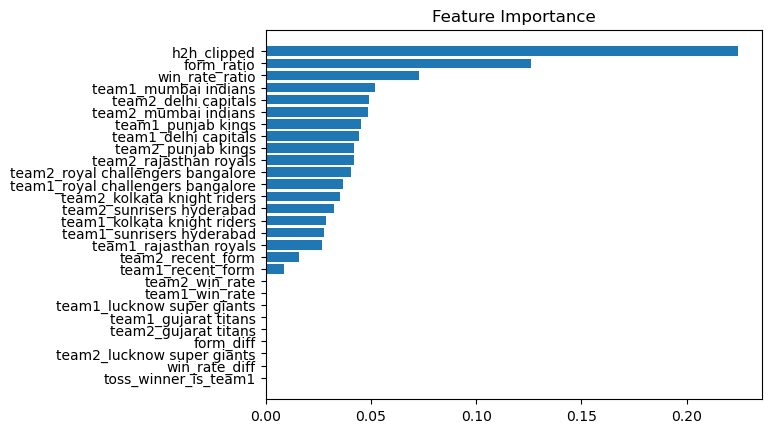

In [32]:
import matplotlib.pyplot as plt

importance = rf_model.feature_importances_

feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print("\nTop Features:")
print(feat_df.head(10))

plt.figure()
plt.barh(feat_df["Feature"], feat_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

In [33]:
print("\n📊 Model Comparison:")
print("Random Forest:", rf_acc)
print("XGBoost:", xgb_acc)


📊 Model Comparison:
Random Forest: 0.5027932960893855
XGBoost: 0.49162011173184356


In [34]:
best_model = xgb_model if xgb_acc > rf_acc else rf_model

with open("../models/best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Best model saved successfully!")

Best model saved successfully!


In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[41 43]
 [47 48]]
